In [1]:
import uproot
import os
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import pandas as pd
from matplotlib.patches import Patch

Definimos Variables

In [2]:
#Carpeta donde están guardados todos los outputs de root (directorio de trabajo de python + rootArchives)
base_folder = './rootArchives/posterViena/'



fit_parameters_wo_uncertainties_true = { 'f_CF3':0.09625, 'f_ar_exc*P2A1':0.2905, 'quenching_ratio_ar_ex':0.038,
                   'tau_1_K_cool':0.026,  'K_scint_tau_2':0.070, 'f_CF4':0.291,
                    'quenching_ratio_ar_ion':6.238, 'P_CD':0.671, 'tau3_cont':5,
}



fit_parameters_wo_uncertainties = { 'f_CF3':1, 'f_ar_exc*P2A1':1, 'quenching_ratio_ar_ex':0.038,
                   'tau_1_K_cool':0.026,  'K_scint_tau_2':0.070, 'f_CF4':0.291,
                    'quenching_ratio_ar_ion':6.238, 'P_CD':0.671, 'tau3_cont':5,
}



Datos Ar_CF4

In [3]:
ar_cf4_experimental_concs = np.array([5, 10, 67, 100])
ar_cf4_experimental_phe_e_visir = np.array([0.575117370892018, 0.548826291079812, 0.300156494522691, 0.0926277372262773])
ar_cf4_experimental_phe_e_vis = np.array([0.38287151, 0.38966203, 0.2802068, 0.09335376])
ar_cf4_experimental_errors_vis = np.array([ 0.005477291487030911, 0.010954582974061933, 0.005478365465753865, 0.007668231611893575])
ar_cf4_systematical_errors_vis = 0.2 * ar_cf4_experimental_phe_e_visir
ar_cf4_total_errors_vis = np.sqrt(ar_cf4_experimental_errors_vis**2 + ar_cf4_systematical_errors_vis**2)
ar_cf4_experimental_concs_uv = np.array([5, 67, 100])
ar_cf4_experimental_phe_e_uv = np.array([0.028726486273286868, 0.044033601820777875, 0.03942121448304051])
ar_cf4_experimental_errors_uv = np.array([0.0002735847440548387, 0.000803687969275206, 0.0032635041309454767])
ar_cf4_systematical_errors_uv = 0.2 * ar_cf4_experimental_phe_e_uv
ar_cf4_total_errors_uv = np.sqrt(ar_cf4_experimental_errors_uv**2 + ar_cf4_systematical_errors_uv**2)
E_fields_ar_cf4 = {5:65, 10:78, 67:88, 100:95}


yields_cf4_100_25_mbar = {'vis':0.04953590534192422, 'uv':0.1367619130620444}
yields_arcf4_8020_25_mbar = {'vis':0.1057123306627957, 'uv':0.02769685258037305}
yields_arcf4_8020_1_bar = {'vis':0.3542058185498147, 'uv':0.04599727051007351 }

Datos He_CF4

In [4]:
he_cf4_experimental_concs = np.array([20, 40, 100])
he_cf4_experimental_phe_e_visir = np.array([0.0668231611893583, 0.0701095461658841, 0.0926277372262773])
he_cf4_experimental_phe_e_vis = np.array([0.05981728, 0.0633149, 0.09335376])
he_cf4_experimental_errors_vis = np.array([0.010954582974061822, 0.019718249353311457, 0.007668231611893575])
he_cf4_systematical_errors_vis = 0.2 * he_cf4_experimental_phe_e_vis
he_cf4_total_errors_vis = np.sqrt(he_cf4_systematical_errors_vis**2 + he_cf4_experimental_errors_vis**2)
he_cf4_experimental_phe_e_uv = np.array([0.0586689111317149, 0.12606696047521188, 0.03942121448304051])
he_cf4_experimental_errors_uv = np.array([0.009617824771399473, 0.03545622383551968, 0.0032635041309454767])
he_cf4_systematical_errors_uv = 0.2 * he_cf4_experimental_phe_e_uv
he_cf4_total_errors_uv = np.sqrt(he_cf4_systematical_errors_uv**2 + he_cf4_experimental_errors_uv**2)

E_fields_he_cf4 = {20: 60, 40:75, 100:95}


yields_hecf4_8020_300_mbar = {'vis':0.03459508998978698, 'uv':0.0709633243946791}

Definimos funciones

In [ ]:
def open_root(P, gas_a, concetracion, E_field, gap, npe, gas_b='cf4', **kwargs):

    P_str = f'{P:.3f}'.rstrip('0').rstrip('.')

    if concetracion == 100:
        root_path = base_folder + f'ar100.0{gas_b}_{E_field:.1f}kVcm_{P_str}bar_{gap:.2f}mm_{npe:d}npe.root'

    else:
        root_path = base_folder + f'{gas_a}{concetracion:.1f}{gas_b}_{E_field:.1f}kVcm_{P_str}bar_{gap:.2f}mm_{npe:d}npe.root'

    root_file = uproot.open(root_path)

    hLevels = root_file['hLevels'].values()

    return root_file, hLevels


In [6]:
def ph_e(Pressure, gas_a, conc_a, conc_b, E_field, gap, npe, n_start_ar=0, n_start_he=0, n_start_cf4=0, gas_b='cf4', tope=False, **kwargs):

    root_file, hLevels = open_root(Pressure, gas_a, conc_a, conc_b, E_field, gap, npe, gas_b, **kwargs)


    n_e = sum(root_file['dataPerPrimaryElectron;1']['nElectrons'].array())
    n_i = sum(root_file['dataPerPrimaryElectron;1']['nIons'].array())

    n_exc_ar_vis, n_exc_he_vis, n_ion_ar_uv, n_ion_he_uv = 0, 0, 0, 0
    n_exc_vis, n_ion_uv, n_exc_dir_vis, n_ion_dir_uv = 0, 0, 0, 0

    if conc_b == 100:
            index_start_direct = 23 + n_start_cf4

            if tope:
                n_exc_dir_vis = sum(hLevels[index_start_direct : 44])
            else:
                n_exc_dir_vis = sum(hLevels[index_start_direct:])

            n_ion_dir_uv = hLevels[1] + hLevels[6] #Canal directo es el que produce CF3+ de algún modo

            

    else:
        
        if gas_a == 'ar':
            index_start_ar = 8 + n_start_ar #seleccionamos desde que estado empezamos a contar
            n_exc_ar_vis = sum(hLevels[index_start_ar:52])
            n_exc_vis = n_exc_ar_vis
            index_start_direct = 75 + n_start_cf4
            if tope:
                n_exc_dir_vis = sum(hLevels[index_start_direct : 96])
            else:
                n_exc_dir_vis = sum(hLevels[index_start_direct:])

            n_ion_ar_uv = hLevels[2] + hLevels[3]#0 #non encontro ionizacións dobles e triples, a sección eficaz debe ser baixa
            n_ion_uv = n_ion_ar_uv
            n_ion_dir_uv = hLevels[53] + hLevels[58] + hLevels[60]#Canal directo es el que produce CF3+ de algún modo

        elif gas_a == 'he':
            index_start_he = 4 + n_start_he
            n_exc_he_vis = 0#sum(hLevels[index_start_he:53])
            n_exc_vis = n_exc_he_vis
            index_start_direct = 76 + n_start_cf4
            if tope:
                n_exc_dir_vis = sum(hLevels[index_start_direct : 97])
            else:
                n_exc_dir_vis = sum(hLevels[index_start_direct:])

            n_ion_he_uv = 0#hLevels[1] #A energía de ionización do helio e 24.59 eV, suficiente para ionizar CF4
            n_ion_uv = n_ion_he_uv
            n_ion_dir_uv = hLevels[54] + hLevels[59] + hLevels[61]#Canal directo es el que produce CF3+ de algún modo

        else:
            print(f'El gas A introducido: {gas_a} no es válido')

    conc_b *= 1e-2
    conc_a *= 1e-2

    ph_e_vis = n_exc_dir_vis / n_e * kwargs['f_CF3'] + n_exc_vis / n_e * kwargs['f_ar_exc*P2A1'] * (1 / (
            1 + conc_a / conc_b * kwargs['quenching_ratio_ar_ex']) )
    
    ph_e_uv = (n_ion_dir_uv / n_e * kwargs['f_CF4']+ n_ion_uv / n_e * ( conc_b * kwargs['quenching_ratio_ar_ion'] / ( 
            1 / kwargs['tau3_cont']  + conc_b * kwargs['quenching_ratio_ar_ion']) ) * kwargs['P_CD']) * (
              conc_b / ( conc_b + kwargs['tau_1_K_cool']
             )  * 1 / (1 + kwargs['K_scint_tau_2'] * conc_b))
    
    ph_i_vis = n_exc_dir_vis / n_i * kwargs['f_CF3'] + n_exc_vis / n_i * kwargs['f_ar_exc*P2A1'] * (1 / (
            1 + conc_a / conc_b * kwargs['quenching_ratio_ar_ex']) )
    
    ph_i_uv = (n_ion_dir_uv / n_i * kwargs['f_CF4']+ n_ion_uv / n_i * ( Pressure * conc_b * kwargs['quenching_ratio_ar_ion'] / ( 
            1 / kwargs['tau3_cont']  + Pressure * conc_b * kwargs['quenching_ratio_ar_ion']) ) * kwargs['P_CD']) * (
             Pressure * conc_b / ( Pressure * conc_b + kwargs['tau_1_K_cool']
            )  * 1 / (1 + kwargs['K_scint_tau_2'] * conc_b))
    
    dic_values = {
        'n_exc_ar_vis':n_exc_ar_vis, 'n_exc_he_vis':n_exc_he_vis, 'n_ion_ar_uv':n_ion_ar_uv, 
        'n_ion_he_uv':n_ion_he_uv, 'n_exc_dir_vis':n_exc_dir_vis, 'n_ion_dir_uv':n_ion_dir_uv,
    }

    return ph_e_vis, ph_e_uv, ph_i_vis, ph_i_uv, dic_values

In [7]:
def ph_e_alternativ(Pressure, gas_a, conc_a, conc_b, E_field, gap, npe, n_start_ar=0, n_start_he=0, n_start_cf4=0, gas_b='cf4', tope=False, **kwargs):

    root_file, hLevels = open_root(Pressure, gas_a, conc_a, conc_b, E_field, gap, npe, gas_b, **kwargs)


    n_e = sum(root_file['dataPerPrimaryElectron;1']['nElectrons'].array())
    n_i = sum(root_file['dataPerPrimaryElectron;1']['nIons'].array())

    n_exc_ar_vis, n_exc_he_vis, n_ion_ar_uv, n_ion_he_uv = 0, 0, 0, 0
    n_exc_vis, n_ion_uv, n_exc_dir_vis, n_ion_dir_uv = 0, 0, 0, 0

    if conc_b == 100:
            index_start_direct = 23 + n_start_cf4

            if tope:
                n_exc_dir_vis = sum(hLevels[index_start_direct : 44])
            else:
                n_exc_dir_vis = sum(hLevels[index_start_direct:])

            n_ion_dir_uv = hLevels[1] + hLevels[6] #Canal directo es el que produce CF3+ de algún modo

            

    else:
        
        if gas_a == 'ar':
            index_start_ar = 8 + n_start_ar #seleccionamos desde que estado empezamos a contar
            n_exc_ar_vis = sum(hLevels[index_start_ar:52])
            n_exc_vis = n_exc_ar_vis
            index_start_direct = 75 + n_start_cf4
            if tope:
                n_exc_dir_vis = sum(hLevels[index_start_direct : 96])
            else:
                n_exc_dir_vis = sum(hLevels[index_start_direct:])

            n_ion_ar_uv = hLevels[2] + hLevels[3]#0 #non encontro ionizacións dobles e triples, a sección eficaz debe ser baixa
            n_ion_uv = n_ion_ar_uv
            n_ion_dir_uv = hLevels[53] + hLevels[58] + hLevels[60]#Canal directo es el que produce CF3+ de algún modo

        elif gas_a == 'he':
            index_start_he = 4 + n_start_he
            n_exc_he_vis = 0#sum(hLevels[index_start_he:53])
            n_exc_vis = n_exc_he_vis
            index_start_direct = 76 + n_start_cf4
            if tope:
                n_exc_dir_vis = sum(hLevels[index_start_direct : 97])
            else:
                n_exc_dir_vis = sum(hLevels[index_start_direct:])

            n_ion_he_uv = 0#hLevels[1] #A energía de ionización do helio e 24.59 eV, suficiente para ionizar CF4
            n_ion_uv = n_ion_he_uv
            n_ion_dir_uv = hLevels[54] + hLevels[59] + hLevels[61]#Canal directo es el que produce CF3+ de algún modo

        else:
            print(f'El gas A introducido: {gas_a} no es válido')

    conc_b *= 1e-2
    conc_a *= 1e-2

    ph_e_vis = n_exc_dir_vis / n_e * kwargs['f_CF3'] + n_exc_vis / n_e * kwargs['f_ar_exc*P2A1'] * (Pressure / (
            1 / (200 * conc_b) + Pressure +  Pressure * conc_a / conc_b * kwargs['quenching_ratio_ar_ex']) )
    
    

    return ph_e_vis

In [ ]:
def array_ph_e(P_start, P_stop, P_step, E_field, dic_Ps, Pressure, conc_a, conc_b, gas_a, gap, npe, tope=False, **kwargs):
    ph_e_vis_array = []
    ph_i_vis_array = []
    ph_e_uv_array = []
    ph_i_uv_array = []
    #E_field = dic_E_fields[conc_b]

    for P in np.arange(P_start, P_stop, P_step):
        P = round(P, 2)

        n_start_transfer, n_start_dir = dic_Ps[P]

        if gas_a == 'ar':
            ph_e_vis, ph_e_uv, ph_i_vis, ph_i_uv, dic_values = ph_e(
                Pressure, 'ar', conc_a, conc_b, E_field, gap, npe, tope=tope, n_start_ar=n_start_transfer,
                n_start_cf4=n_start_dir, **kwargs
            )

        elif gas_a == 'he':
            ph_e_vis, ph_e_uv, ph_i_vis, ph_i_uv, dic_values = ph_e(
                Pressure, 'he', conc_a, conc_b, E_field, gap, npe, tope=tope ,n_start_he=n_start_transfer,
                n_start_cf4=n_start_dir, **kwargs
            )

        ph_e_vis_array.append(P * ph_e_vis)
        ph_i_vis_array.append(P * ph_i_vis)
        ph_e_uv_array.append(ph_e_uv)
        ph_i_uv_array.append(ph_i_uv)

    return ph_e_vis_array, ph_i_vis_array, ph_e_uv_array, ph_i_uv_array

In [9]:
def compute_lifetime_influence(Pressure, conc_b, **kwargs):
    f_b = conc_b * 1e-2
    f_a = 1 - f_b 

    tau_term = 1 / (200 * f_b)
    quenching_term = Pressure +  Pressure * f_a / f_b * kwargs['quenching_ratio_ar_ex'] 

    return tau_term / quenching_term

In [10]:
rows_tau_effect = []
for pressure in np.linspace(0.025, 3, 20):
    for conc in np.logspace(-1, 2, 10):
        ratio = compute_lifetime_influence(pressure, conc, **fit_parameters_wo_uncertainties)
        rows_tau_effect.append({
            'Conc CF4': conc,
            'Pressure (bar)': pressure,
            'Ratio tau_quenching': ratio,
        })

df_tau_effect = pd.DataFrame(rows_tau_effect)

Miramos Penning

In [ ]:
rows = []
index_start_CF3_penning = 95
for conc_b in ar_cf4_experimental_concs:
    root_file, hLevels = open_root(1, 'ar', 100-conc_b, conc_b, E_fields_ar_cf4[conc_b], 0.05, 10000)

    n_e = sum(root_file['dataPerPrimaryElectron;1']['nElectrons'].array())


    N_CF3 = sum(hLevels[index_start_CF3_penning:])


    penning = N_CF3 / n_e

    gap = 0.05

    rows.append({
        'conc CF4':       conc_b,
        'n_e (10000 primaries)':          n_e,
        'penning (per secondary e-)':      penning,
        'E_field (kV/cm)':      E_fields_ar_cf4[conc_b],
        'gap (cm)':          gap / 10,
        'Pressure (bar)':       1
    })




root_file, hLevels = open_root(1, 'ar', 80, 20, 29, 0.57, 10000)
n_e = sum(root_file['dataPerPrimaryElectron;1']['nElectrons'].array())
N_CF3 = sum(hLevels[index_start_CF3_penning:])
penning = N_CF3 / n_e
gap = 0.57
rows.append({
    'conc CF4':       20,
    'n_e (10000 primaries)':          n_e,
    'penning (per secondary e-ax_labels_ar_f)':      penning,
    'E_field (kV/cm)':      29,
    'gap (cm)':          gap / 10,
    'Pressure (bar)':       1
})


root_file, hLevels = open_root(0.025, 'ar', 0, 100, 10, 0.57, 10000)
n_e = sum(root_file['dataPerPrimaryElectron;1']['nElectrons'].array())
N_CF3 = sum(hLevels[index_start_CF3_penning:])
penning = N_CF3 / n_e
gap = 0.57
rows.append({
    'conc CF4':       100,
    'n_e (10000 primaries)':          n_e,
    'penning (per secondary e-)':      penning,
    'E_field (kV/cm)':      10,
    'gap (cm)':          gap / 10,
    'Pressure (bar)':       0.025
})


root_file, hLevels = open_root(0.05, 'ar', 80, 20, 8.4, 0.57, 10000)
n_e = sum(root_file['dataPerPrimaryElectron;1']['nElectrons'].array())
N_CF3 = sum(hLevels[index_start_CF3_penning:])
penning = N_CF3 / n_e
gap = 0.57
rows.append({
    'conc CF4':       20,
    'n_e (10000 primaries)':          n_e,
    'penning (per secondary e-)':      penning,
    'E_field (kV/cm)':      8.4,
    'gap (cm)':          gap / 10,
    'Pressure (bar)':       0.05
})

df = pd.DataFrame(rows)

Variables sin tope

In [12]:
dic_Ps_to_states_5 = {0.1:(0, 0), 0.15:(0, 11), 0.2:(0, 12), 0.25:(1, 14), 0.3:(3, 17), 0.35:(3, 19),
                    0.4:(5, 19), 0.45:(11, 20), 0.5:(15, 20), 0.55:(16, 21), 0.6:(18, 21), 
                    0.65:(21, 22), 0.7:(23, 22), 0.75:(23, 22), 0.8:(24, 22), 0.85:(26, 23), 
                    0.9:(29, 23), 0.95:(29, 23), 1:(29, 23)}

dic_Ps_to_states_10 = {0.1:(0, 0), 0.15:(0, 11), 0.2:(0, 12), 0.25:(1, 14), 0.3:(3, 17), 0.35:(3, 19),
                    0.4:(6, 19), 0.45:(12, 20), 0.5:(15, 20), 0.55:(17, 21), 0.6:(19, 21), 
                    0.65:(21, 21), 0.7:(23, 22), 0.75:(23, 22), 0.8:(24, 22), 0.85:(27, 23), 
                    0.9:(29, 23), 0.95:(29, 23), 1:(29, 23)}

dic_Ps_to_states_20 = {0.1: (0, 0), 0.15: (0, 11), 0.2: (0, 12), 0.25: (2, 13), 0.3: (3, 17), 0.35: (3, 19), 
                       0.4: (7, 19), 0.45: (13, 20), 0.5: (15, 20), 0.55: (17, 21), 0.6: (19, 21), 0.65: (21, 21), 
                       0.7: (23, 22), 0.75: (23, 22), 0.8: (24, 22), 0.85: (26, 23), 0.9: (29, 23), 0.95: (29, 23), 
                       1.0: (29, 23)}

dic_Ps_to_states_67 = {0.1:(0, 0), 0.15:(0, 11), 0.2:(0, 12), 0.25:(2, 13), 0.3:(3, 15), 0.35:(3, 18),
                    0.4:(8, 19), 0.45:(13, 19), 0.5:(15, 20), 0.55:(17, 20), 0.6:(18, 21), 
                    0.65:(20, 21), 0.7:(23, 21), 0.75:(23, 22), 0.8:(23, 22), 0.85:(24, 22), 
                    0.9:(26, 22), 0.95:(29, 23), 1:(29, 23)}

dic_Ps_to_states_100 = {0.1:(0, 0), 0.15:(0, 11), 0.2:(0, 12), 0.25:(1, 12), 0.3:(3, 14), 0.35:(3, 16),
                    0.4:(6, 18), 0.45:(12, 19), 0.5:(15, 19), 0.55:(17, 20), 0.6:(19, 20), 
                    0.65:(21, 20), 0.7:(23, 21), 0.75:(23, 21), 0.8:(24, 21), 0.85:(27, 22), 
                    0.9:(29, 22), 0.95:(29, 22), 1:(29, 22)}

dic_Ps_to_states_he_20 = {0.1: (0, 0), 0.15: (0, 11), 0.2: (0, 12), 0.25: (1, 12), 0.3: (3, 13), 
                          0.35: (3, 15), 0.4: (3, 18), 0.45: (3, 19), 0.5: (3, 19), 0.55: (3, 19), 
                          0.6: (3, 20), 0.65: (3, 20), 0.7: (4, 20), 0.75: (6, 21), 0.8: (8, 21), 0.85: 
                          (9, 21), 0.9: (9, 22), 0.95: (9, 22), 1.0: (9, 22)}

dic_Ps_to_states_he_40 = {0.1: (0, 0), 0.15: (0, 11), 0.2: (0, 12), 0.25: (1, 12), 0.3: (3, 13), 
                          0.35: (3, 16), 0.4: (3, 18), 0.45: (3, 19), 0.5: (3, 19), 0.55: (3, 20), 
                          0.6: (3, 20), 0.65: (3, 20), 0.7: (4, 21), 0.75: (5, 21), 0.8: (8, 21), 
                          0.85: (9, 22), 0.9: (9, 22), 0.95: (9, 22), 1.0: (9, 22)} #Feito con Degrad de He/CF4 de 50/50


Variables con tope

In [13]:
dic_Ps_to_states_5_con_tope = {0.1: (0, 0), 0.15: (0, 9), 0.2: (0, 11), 0.25: (1, 12), 0.3: (3, 12),
                             0.35: (3, 12), 0.4: (5, 13), 0.45: (11, 14), 0.5: (15, 14), 0.55: (16, 15),
                             0.6: (18, 16), 0.65: (21, 17), 0.7: (23, 18), 0.75: (23, 18), 0.8: (24, 18),
                             0.85: (26, 18), 0.9: (29, 18), 0.95: (29, 19), 1.0: (29, 19)}

dic_Ps_to_states_10_con_tope =  {0.1: (0, 0), 0.15: (0, 9), 0.2: (0, 11), 0.25: (1, 12), 0.3: (3, 12),
                                0.35: (3, 12), 0.4: (6, 13), 0.45: (12, 13), 0.5: (15, 14), 0.55: (17, 15), 
                                0.6: (19, 16), 0.65: (21, 17), 0.7: (23, 18), 0.75: (23, 18), 0.8: (24, 18), 
                                0.85: (27, 18), 0.9: (29, 18), 0.95: (29, 19), 1.0: (29, 19)}

dic_Ps_to_states_67_con_tope = {0.1: (0, 0), 0.15: (0, 9), 0.2: (0, 11), 0.25: (2, 12), 0.3: (3, 12), 
                                0.35: (3, 12), 0.4: (8, 13), 0.45: (13, 13), 0.5: (15, 14), 0.55: (17, 14), 
                                0.6: (18, 15), 0.65: (20, 16), 0.7: (23, 17), 0.75: (23, 17), 0.8: (23, 18), 0.85: 
                                (24, 18), 0.9: (26, 18), 0.95: (29, 18), 1.0: (29, 19)}


dic_Ps_to_states_100_con_tope = {0.1: (0, 0), 0.15: (0, 9), 0.2: (0, 11), 0.25: (0, 12), 0.3: (0, 12),
                                 0.35: (0, 12), 0.4: (0, 12), 0.45: (0, 13), 0.5: (0, 13), 0.55: (0, 14),
                                 0.6: (0, 14), 0.65: (0, 15), 0.7: (0, 16), 0.75: (0, 17), 0.8: (0, 17), 
                                 0.85: (0, 18), 0.9: (0, 18), 0.95: (0, 18), 1.0: (0, 18)}


dic_Ps_to_states_he_20_con_tope = {0.1: (200, 0), 0.15: (200, 9), 0.2: (200, 11), 0.25: (200, 12), 0.3: (200, 12),
                                    0.35: (200, 12), 0.4: (200, 12), 0.45: (200, 13), 0.5: (200, 13), 0.55: (200, 13), 
                                    0.6: (200, 14), 0.65: (200, 15), 0.7: (200, 15), 0.75: (200, 16), 0.8: (200, 17), 0.85: 
                                    (200, 17), 0.9: (200, 18), 0.95: (200, 18), 1.0: (200, 18)}


dic_Ps_to_states_he_40_con_tope = {0.1: (200, 0), 0.15: (200, 9), 0.2: (200, 11), 0.25: (200, 12), 0.3: (200, 12), 
                                   0.35: (200, 12), 0.4: (200, 12), 0.45: (200, 13), 0.5: (200, 13), 0.55: (200, 14), 
                                   0.6: (200, 14), 0.65: (200, 15), 0.7: (200, 16), 0.75: (200, 17), 0.8: (200, 17), 
                                   0.85: (200, 18), 0.9: (200, 18), 0.95: (200, 18), 1.0: (200, 18)} #Feito con Degrad de He/CF4 de 50/50


(0.0, 0.6293794209011119)

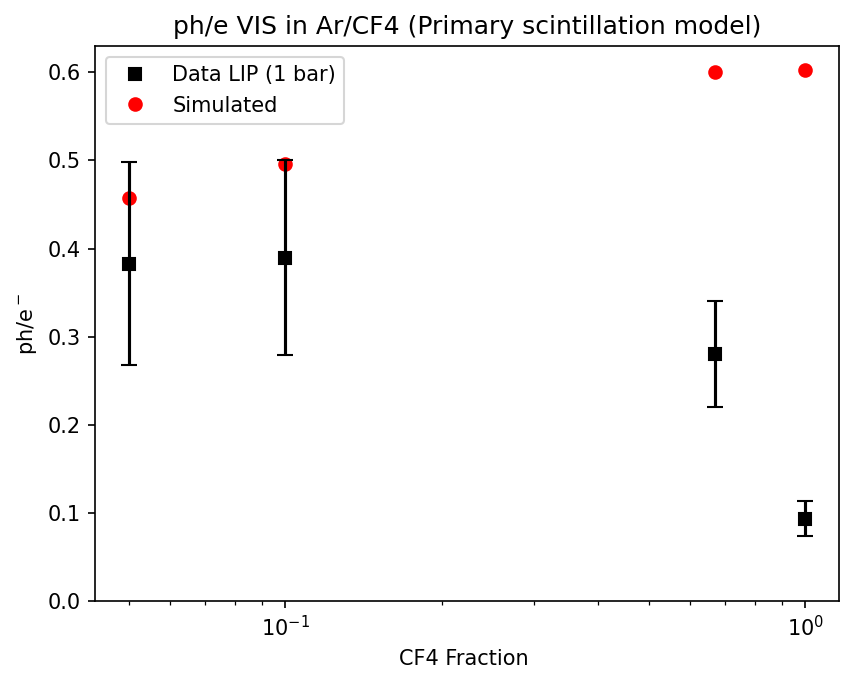

In [14]:
fig_ar_all, ax_ar_all = plt.subplots(dpi=150)

list_dic_Ps_to_states = [dic_Ps_to_states_5[0.1], dic_Ps_to_states_10[0.1], dic_Ps_to_states_67[0.1], dic_Ps_to_states_100[0.1]]
list_colors = ['g', 'k', 'r', 'b']

for conc_b, c, ph_e_experimental, list_starting_states, error in zip(ar_cf4_experimental_concs, list_colors, ar_cf4_experimental_phe_e_vis, list_dic_Ps_to_states, ar_cf4_total_errors_vis):

    n_start_transfer, n_start_dir = list_starting_states
    ph_e_vis, ph_e_uv, ph_i_vis, ph_i_uv, dic_values = ph_e(1, 'ar', 100-conc_b, conc_b, E_fields_ar_cf4[conc_b],
                                                            0.05, 10000, n_start_ar=n_start_transfer, n_start_cf4=n_start_dir, **fit_parameters_wo_uncertainties)
    
    ax_ar_all.plot(conc_b/100, ph_e_vis * 0.35, 'o', color='r', label=f'Sim VIS {conc_b}% CF4')
    ax_ar_all.errorbar(conc_b/100, ph_e_experimental, marker='s', color='k', yerr=error, label=f'Exp VIS {conc_b}% CF4', capsize=4)


ax_ar_all.legend()
ax_ar_all.set_xlabel('CF4 Fraction ')
ax_ar_all.set_ylabel('ph/e$^-$')
ax_ar_all.set_title('ph/e VIS in Ar/CF4 (Primary scintillation model)')
ax_ar_all.set_xscale('log')


legend_elements_all = [

    Line2D([0], [0], markerfacecolor='k', color='k', label='Data LIP (1 bar)', marker='s', linestyle='None'),
    Line2D([0], [0], markerfacecolor='r', color='r', label='Simulated', marker='o', linestyle='None'),

]

ax_ar_all.legend(handles=legend_elements_all, loc='best')

ax_ar_all.set_ylim(0)


Text(0.5, 1.0, 'ph/$e^-$ vis  Ar/CF4')

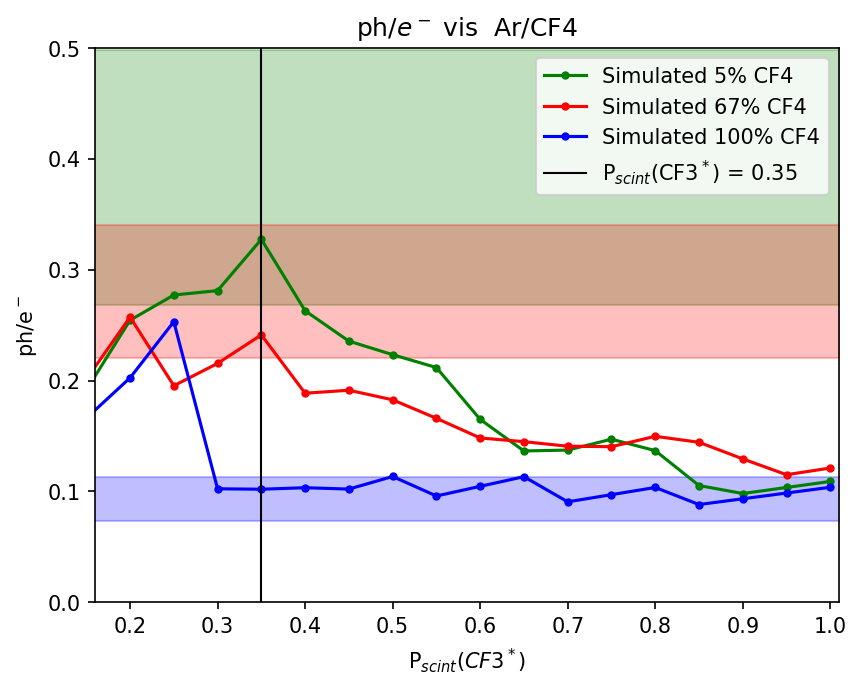

In [15]:
chi2s_list = []
fig_ar, ax_ar = plt.subplots(dpi=150)
list_dic_Ps_to_states = [dic_Ps_to_states_5, dic_Ps_to_states_10, dic_Ps_to_states_67, dic_Ps_to_states_100]

for dic_P, conc_b, ph_e_experimental, c, error in zip(list_dic_Ps_to_states, ar_cf4_experimental_concs, ar_cf4_experimental_phe_e_vis, list_colors, ar_cf4_total_errors_vis):
    E_field = E_fields_ar_cf4[conc_b]
    
    
    ph_e_vis_plot, ph_i_vis_plot, ph_e_uv_plot, ph_i_uv_plot = array_ph_e(0.1, 1.01, 0.05, E_field, dic_P, 1, 100-conc_b, conc_b, 'ar', 0.05, 10000, **fit_parameters_wo_uncertainties)
    if conc_b != 10:
        #ax_ar.axhline(ph_e_experimental, label=f'Experimental {conc_b:d}% CF4', color=c)
        ax_ar.fill_between(np.arange(0.1, 1.06, 0.05), ph_e_experimental - error, ph_e_experimental + error, color=c, alpha=0.25)
        ax_ar.plot(np.arange(0.1, 1.01, 0.05), ph_e_vis_plot, '.-', label=f'Simulated {conc_b:d}% CF4', color=c)
    #ax_ar.plot(np.arange(0.1, 1.01, 0.05), ph_i_vis_plot, '^', label=f'Simulated {conc_b:d}% CF4', color=c)


    chi2_individual = np.array([(ph_e - ph_e_experimental) ** 2 / error ** 2  for ph_e in ph_e_vis_plot])
    # ax_chi2_ar_vis.plot(np.arange(0.1, 1.01, 0.05), chi2_individual, '.', color=c, label=f'{conc_b}% CF4')
    # ax_chi2_ar_vis.plot(np.arange(0.1, 1.01, 0.05), chi2_individual, '-', color=c)
    chi2s_list.append(chi2_individual)


ax_ar.axvline(0.35, color='k', linewidth=1, label='P$_{scint}$(CF3$^*$) = 0.35')

ax_ar.set_ylim(0, 0.5)
ax_ar.set_xlim(0.16, 1.01)
ax_ar.legend()
ax_ar.set_xlabel('P$_{scint} (CF3^*)$')
ax_ar.set_ylabel('ph/e$^-$')
ax_ar.set_title('ph/$e^-$ vis  Ar/CF4')




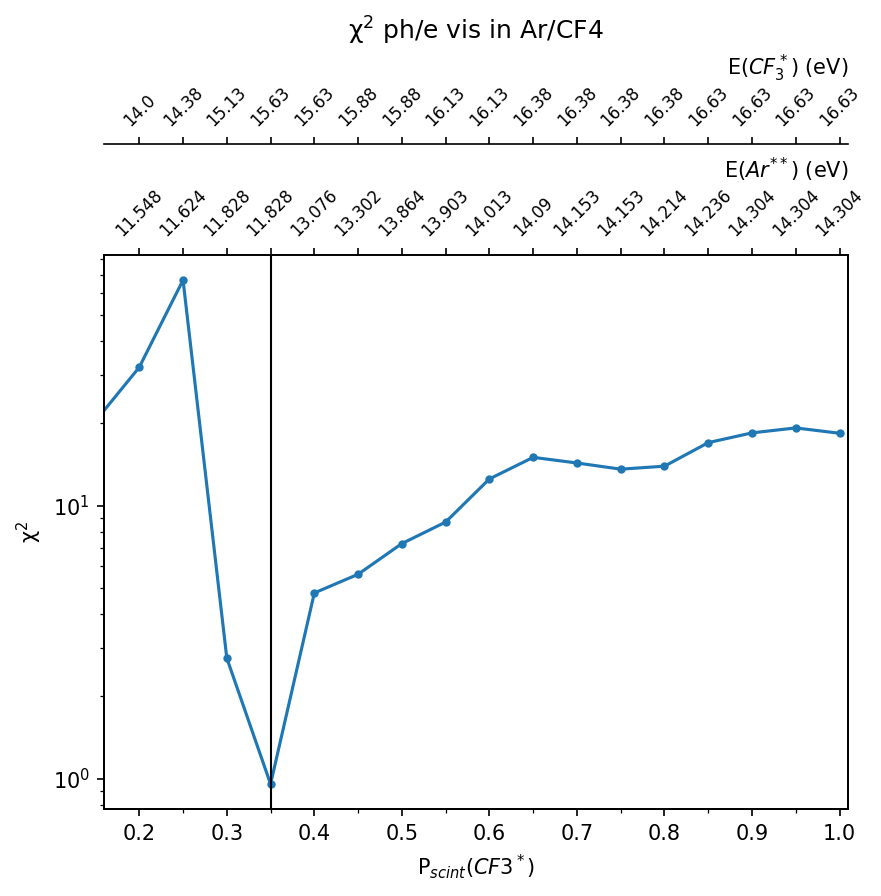

In [16]:
fig_chi2_ar_vis, ax_chi2_ar_vis = plt.subplots(dpi=150)


chi2 = sum(chi2s_list)
#ax_chi2_ar_vis.set_ylim(0, 10)
x_vals = np.arange(0.1, 1.01, 0.05)
ax_chi2_ar_vis.plot(x_vals, chi2, '.-')


ax_chi2_ar_vis.set_xlabel('P$_{scint} (CF3^*)$')
ax_chi2_ar_vis.set_ylabel('\u03C7$^2$')
ax_chi2_ar_vis.set_title('\u03C7$^2$ ph/e vis in Ar/CF4')
ax_chi2_ar_vis.set_yscale('log')


levels_ar_cf4 = pd.read_csv('./Ar_CF4_levels.csv')

mask_excited = levels_ar_cf4['estado_excit'].notna()
data_excited = levels_ar_cf4[mask_excited]

mask_direct = levels_ar_cf4['f_osc'].notna()
data_direct = levels_ar_cf4[mask_direct]


ax_labels_ar = []

ax_labels_cf4 = []

for key, (idx_ar, idx_cf4) in dic_Ps_to_states_5.items():

    ax_labels_ar.append(data_excited.iloc[idx_ar]['energia_eV'])
    ax_labels_cf4.append(data_direct.iloc[idx_cf4]['energia_eV'])


ax_labels_ar_f = []
ax_labels_cf4_f = []
for P_CF3 in np.arange(0.1, 1.01, 0.05):
    ax_labels_ar_f.append(f"{0.2056 / P_CF3:.3f}")
    ax_labels_cf4_f.append(f"{0.09625 / P_CF3:.3f}")



ax_top_ar = ax_chi2_ar_vis.twiny()

ax_top_ar.set_xlim(ax_chi2_ar_vis.get_xlim())

ax_top_ar.set_xticks(x_vals)
ax_top_ar.set_xticklabels(ax_labels_ar, rotation=45, fontsize=8)

ax_top_ar.set_xlabel("E($Ar^{**}$) (eV)", loc='right')







ax_top_cf4 = ax_chi2_ar_vis.twiny()

ax_top_cf4.set_xlim(ax_chi2_ar_vis.get_xlim())

# mover este eje más arriba
ax_top_cf4.spines['top'].set_position(('axes', 1.2))

ax_top_cf4.set_xticks(x_vals)
ax_top_cf4.set_xticklabels(ax_labels_cf4, rotation=45, fontsize=8)

ax_top_cf4.set_xlabel("E(${CF_3^*}$) (eV)", loc='right')


ax_chi2_ar_vis.set_xticks(np.arange(0.1, 1.01, 0.05), minor= True)
#ax_chi2_ar_vis.grid(which='both', axis='x')

ax_chi2_ar_vis.set_xlim(0.16, 1.01)
ax_top_ar.set_xlim(0.16, 1.01)
ax_top_cf4.set_xlim(0.16, 1.01)
ax_chi2_ar_vis.axvline(0.35, color='k', linewidth=1)


(0.0, 0.5230263502580887)

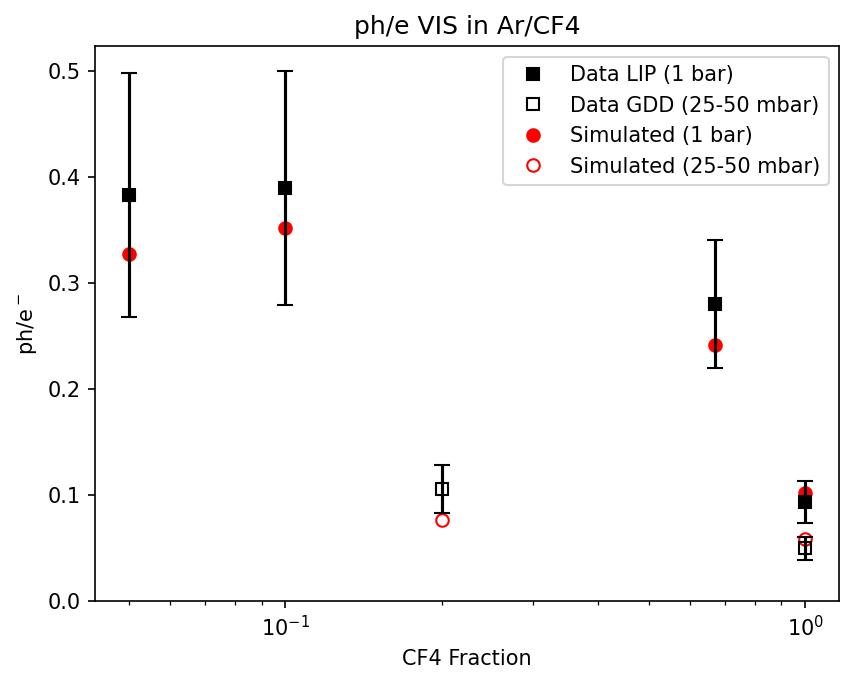

In [17]:
fig_ar_vis, ax_ar_vis = plt.subplots(dpi=150)

list_dic_Ps_to_states = [dic_Ps_to_states_5[0.35], dic_Ps_to_states_10[0.35], dic_Ps_to_states_67[0.35], dic_Ps_to_states_100[0.35]]

for conc_b, c, ph_e_experimental, list_starting_states, error in zip(ar_cf4_experimental_concs, list_colors, ar_cf4_experimental_phe_e_vis, list_dic_Ps_to_states, ar_cf4_total_errors_vis):

    n_start_transfer, n_start_dir = list_starting_states

    ph_e_vis, ph_e_uv, ph_i_vis, ph_i_uv, dic_values = ph_e(1, 'ar', 100-conc_b, conc_b, E_fields_ar_cf4[conc_b],
                                                            0.05, 10000, n_start_ar=n_start_transfer, n_start_cf4=n_start_dir, **fit_parameters_wo_uncertainties)
    
    ax_ar_vis.plot(conc_b/100, ph_e_vis * 0.35, 'o', color='r', label=f'Sim VIS {conc_b}% CF4')
    ax_ar_vis.errorbar(conc_b/100, ph_e_experimental, marker='s', color='k', yerr=error, label=f'Exp VIS {conc_b}% CF4', capsize=4)
    


ph_e_vis, ph_e_uv, ph_i_vis, ph_i_uv, dic_values = ph_e(0.025, 'ar', 0, 100, 10,
                            0.57, 10000, n_start_ar=n_start_transfer, n_start_cf4=n_start_dir, **fit_parameters_wo_uncertainties)
ax_ar_vis.plot(1, ph_e_vis * 0.35, 'ro',  markerfacecolor='none',label='Sim VIS 100% CF4, 25 mbar')
ax_ar_vis.errorbar(1, yields_cf4_100_25_mbar['vis'], color='k', marker='s', markerfacecolor='none', yerr=0.5306257209698674 * ar_cf4_total_errors_vis[-1], label='Exp VIS 100% CF4, 25 mbar', capsize=4)


n_start_transfer, n_start_dir = dic_Ps_to_states_20[0.35]
ph_e_vis, ph_e_uv, ph_i_vis, ph_i_uv, dic_values = ph_e(0.05, 'ar', 80, 20, 8.4,
                            0.57, 10000, n_start_ar=n_start_transfer, n_start_cf4=n_start_dir, **fit_parameters_wo_uncertainties)
ax_ar_vis.plot(0.2, ph_e_vis * 0.35, 'ro',  markerfacecolor='none',label='Sim VIS 20% CF4, 50 mbar')
ax_ar_vis.errorbar(0.2, yields_arcf4_8020_25_mbar['vis'], color='k', marker='s', markerfacecolor='none',yerr=1.132384303590726 * ar_cf4_total_errors_vis[-1], label='Exp VIS 20% CF4, 50 mbar', capsize=4)


# n_start_transfer, n_start_dir = dic_Ps_to_states_20[0.35]
# ph_e_vis, ph_e_uv, ph_i_vis, ph_i_uv, dic_values = ph_e(1, 'ar', 80, 20, 29,
#                             0.57, 10000, n_start_ar=n_start_transfer, n_start_cf4=n_start_dir, **fit_parameters_wo_uncertainties)
# ax_ar_vis.plot(0.2, ph_e_vis * 0.35, 'ro', label='Sim VIS 20% CF4, 1 bar')
# ax_ar_vis.errorbar(0.2, yields_arcf4_8020_1_bar['vis'], color='k', marker='o', yerr=3.7942320129687266 * ar_cf4_total_errors_vis[-1], label='Exp VIS 20% CF4, 1 bar', capsize=4)



ax_ar_vis.legend()
ax_ar_vis.set_xlabel('CF4 Fraction')
ax_ar_vis.set_ylabel('ph/e$^-$')
ax_ar_vis.set_title('ph/e VIS in Ar/CF4')
#ax_ar_vis.set_xlim(0, 105)
ax_ar_vis.set_xscale('log')


legend_elements = [


    Line2D([0], [0], marker='s', linestyle='None',
           color='k', markerfacecolor='k', label='Data LIP (1 bar)'),

    Line2D([0], [0], marker='s', linestyle='None',
           color='k', markerfacecolor='none', label='Data GDD (25-50 mbar)'),
           

    Line2D([0], [0], marker='o', linestyle='None',
            color='r', markerfacecolor='r', label='Simulated (1 bar)'),

    Line2D([0], [0], marker='o', linestyle='None',
           color='r', markerfacecolor='none', label='Simulated (25-50 mbar)',
           )
]

ax_ar_vis.legend(handles=legend_elements, loc='best')

ax_ar_vis.set_ylim(0)


(0.0, 0.5230263502580887)

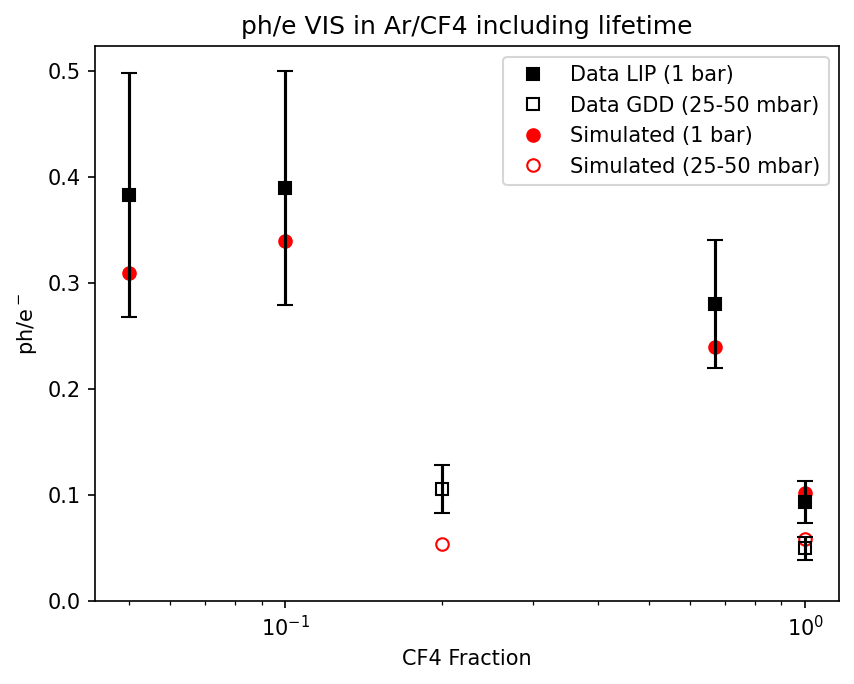

In [18]:
fig_ar_vis_alternativ, ax_ar_vis_alternativ = plt.subplots(dpi=150)

list_dic_Ps_to_states = [dic_Ps_to_states_5[0.35], dic_Ps_to_states_10[0.35], dic_Ps_to_states_67[0.35], dic_Ps_to_states_100[0.35]]

for conc_b, c, ph_e_experimental, list_starting_states, error in zip(ar_cf4_experimental_concs, list_colors, ar_cf4_experimental_phe_e_vis, list_dic_Ps_to_states, ar_cf4_total_errors_vis):

    n_start_transfer, n_start_dir = list_starting_states

    ph_e_vis = ph_e_alternativ(1, 'ar', 100-conc_b, conc_b, E_fields_ar_cf4[conc_b],
                                                            0.05, 10000, n_start_ar=n_start_transfer, n_start_cf4=n_start_dir, **fit_parameters_wo_uncertainties)
    
    ax_ar_vis_alternativ.plot(conc_b/100, ph_e_vis * 0.35, 'o', color='r', label=f'Sim VIS {conc_b}% CF4')
    ax_ar_vis_alternativ.errorbar(conc_b/100, ph_e_experimental, marker='s', color='k', yerr=error, label=f'Exp VIS {conc_b}% CF4', capsize=4)
    


ph_e_vis = ph_e_alternativ(0.025, 'ar', 0, 100, 10,
                            0.57, 10000, n_start_ar=n_start_transfer, n_start_cf4=n_start_dir, **fit_parameters_wo_uncertainties)
ax_ar_vis_alternativ.plot(1, ph_e_vis * 0.35, 'ro',  markerfacecolor='none',label='Sim VIS 100% CF4, 25 mbar')
ax_ar_vis_alternativ.errorbar(1, yields_cf4_100_25_mbar['vis'], color='k', marker='s', markerfacecolor='none', yerr=0.5306257209698674 * ar_cf4_total_errors_vis[-1], label='Exp VIS 100% CF4, 25 mbar', capsize=4)


n_start_transfer, n_start_dir = dic_Ps_to_states_20[0.35]
ph_e_vis = ph_e_alternativ(0.05, 'ar', 80, 20, 8.4,
                            0.57, 10000, n_start_ar=n_start_transfer, n_start_cf4=n_start_dir, **fit_parameters_wo_uncertainties)
ax_ar_vis_alternativ.plot(0.2, ph_e_vis * 0.35, 'ro',  markerfacecolor='none',label='Sim VIS 20% CF4, 50 mbar')
ax_ar_vis_alternativ.errorbar(0.2, yields_arcf4_8020_25_mbar['vis'], color='k', marker='s', markerfacecolor='none',yerr=1.132384303590726 * ar_cf4_total_errors_vis[-1], label='Exp VIS 20% CF4, 50 mbar', capsize=4)


# n_start_transfer, n_start_dir = dic_Ps_to_states_20[0.35]
# ph_e_vis, ph_e_uv, ph_i_vis, ph_i_uv, dic_values = ph_e(1, 'ar', 80, 20, 29,
#                             0.57, 10000, n_start_ar=n_start_transfer, n_start_cf4=n_start_dir, **fit_parameters_wo_uncertainties)
# ax_ar_vis.plot(0.2, ph_e_vis * 0.35, 'ro', label='Sim VIS 20% CF4, 1 bar')
# ax_ar_vis.errorbar(0.2, yields_arcf4_8020_1_bar['vis'], color='k', marker='o', yerr=3.7942320129687266 * ar_cf4_total_errors_vis[-1], label='Exp VIS 20% CF4, 1 bar', capsize=4)



ax_ar_vis_alternativ.legend()
ax_ar_vis_alternativ.set_xlabel('CF4 Fraction')
ax_ar_vis_alternativ.set_ylabel('ph/e$^-$')
ax_ar_vis_alternativ.set_title('ph/e VIS in Ar/CF4 including lifetime')
#ax_ar_vis.set_xlim(0, 105)
ax_ar_vis_alternativ.set_xscale('log')




ax_ar_vis_alternativ.legend(handles=legend_elements, loc='best')

ax_ar_vis_alternativ.set_ylim(0)


0.004893360373131347
0.14211981010328326
0.2651903174979944


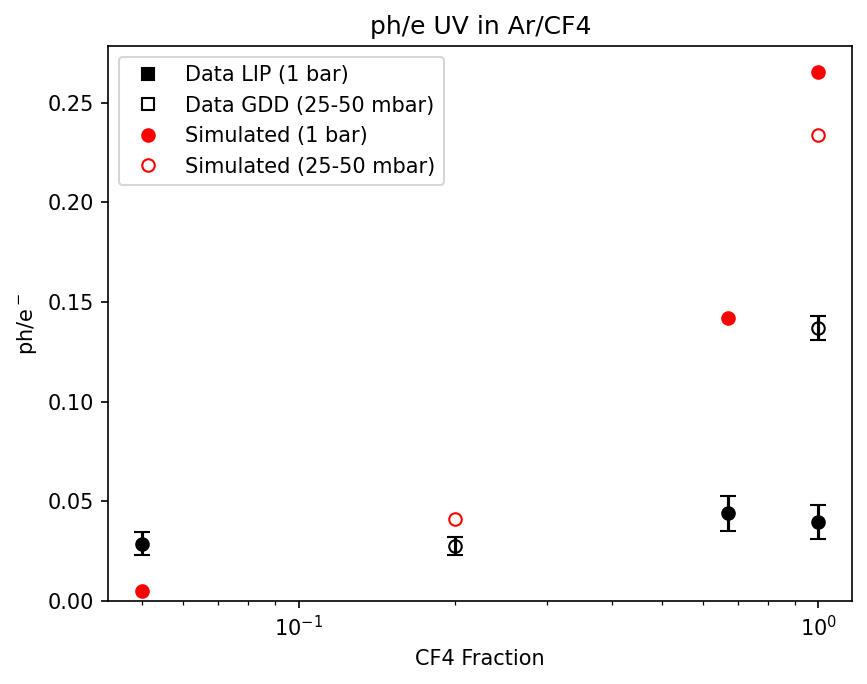

In [19]:
fig_ar_uv, ax_ar_uv = plt.subplots(dpi=150)

list_dic_Ps_to_states = [dic_Ps_to_states_5, dic_Ps_to_states_67, dic_Ps_to_states_100]
list_colors_uv = ['g', 'r', 'b']

for conc_b, c, ph_e_experimental, error in zip(ar_cf4_experimental_concs_uv, list_colors_uv, ar_cf4_experimental_phe_e_uv, ar_cf4_total_errors_uv):
    ph_e_vis, ph_e_uv, ph_i_vis, ph_i_uv, dic_values = ph_e(1, 'ar', 100-conc_b, conc_b, E_fields_ar_cf4[conc_b],
                                                            0.05, 10000, **fit_parameters_wo_uncertainties)
    
    ax_ar_uv.plot(conc_b / 100, ph_e_uv , 'o', color='r', label=f'Simulated UV {conc_b}% CF4')
    ax_ar_uv.errorbar(conc_b / 100, ph_e_experimental, yerr=error, marker='o', color='k', label=f'Experimental UV {conc_b}% CF4', capsize=4)
    print(ph_e_uv)



ph_e_vis, ph_e_uv, ph_i_vis, ph_i_uv, dic_values = ph_e(0.025, 'ar', 0, 100, 10,
                            0.57, 10000, n_start_ar=n_start_transfer, n_start_cf4=n_start_dir, **fit_parameters_wo_uncertainties)
ax_ar_uv.plot(1, ph_e_uv , 'ro', markerfacecolor='none', label='Sim UV 100% CF4, 25 mbar')
ax_ar_uv.errorbar(1, yields_cf4_100_25_mbar['uv'], marker='o', color='k', markerfacecolor='none', yerr= 0.7025875012625137 * ar_cf4_total_errors_uv[-1], label='Exp UV 100% CF4, 25 mbar', capsize=4)


n_start_transfer, n_start_dir = dic_Ps_to_states_20[0.35]
ph_e_vis, ph_e_uv, ph_i_vis, ph_i_uv, dic_values = ph_e(0.025, 'ar', 80, 20, 6.6,
                            0.57, 10000, n_start_ar=n_start_transfer, n_start_cf4=n_start_dir, **fit_parameters_wo_uncertainties)
ax_ar_uv.plot(0.2, ph_e_uv, 'ro', label='Sim UV 20% CF4, 50 mbar', markerfacecolor='none',)
ax_ar_uv.errorbar(0.2, yields_arcf4_8020_25_mbar['uv'], marker='o', color='k', markerfacecolor='none', yerr= 0.5306257209698674 * ar_cf4_total_errors_uv[-1], label='Exp UV 20% CF4, 50 mbar',capsize=4)

ax_ar_uv.legend()
ax_ar_uv.set_xlabel('CF4 Fraction')
ax_ar_uv.set_ylabel('ph/e$^-$')
ax_ar_uv.set_title('ph/e UV in Ar/CF4')
#ax_ar_uv.set_xlim(0, 105)
ax_ar_uv.set_ylim(0)
ax_ar_uv.set_xscale('log')


ax_ar_uv.legend(handles=legend_elements)

Text(0.5, 1.0, 'ph/e vis in He/CF4')

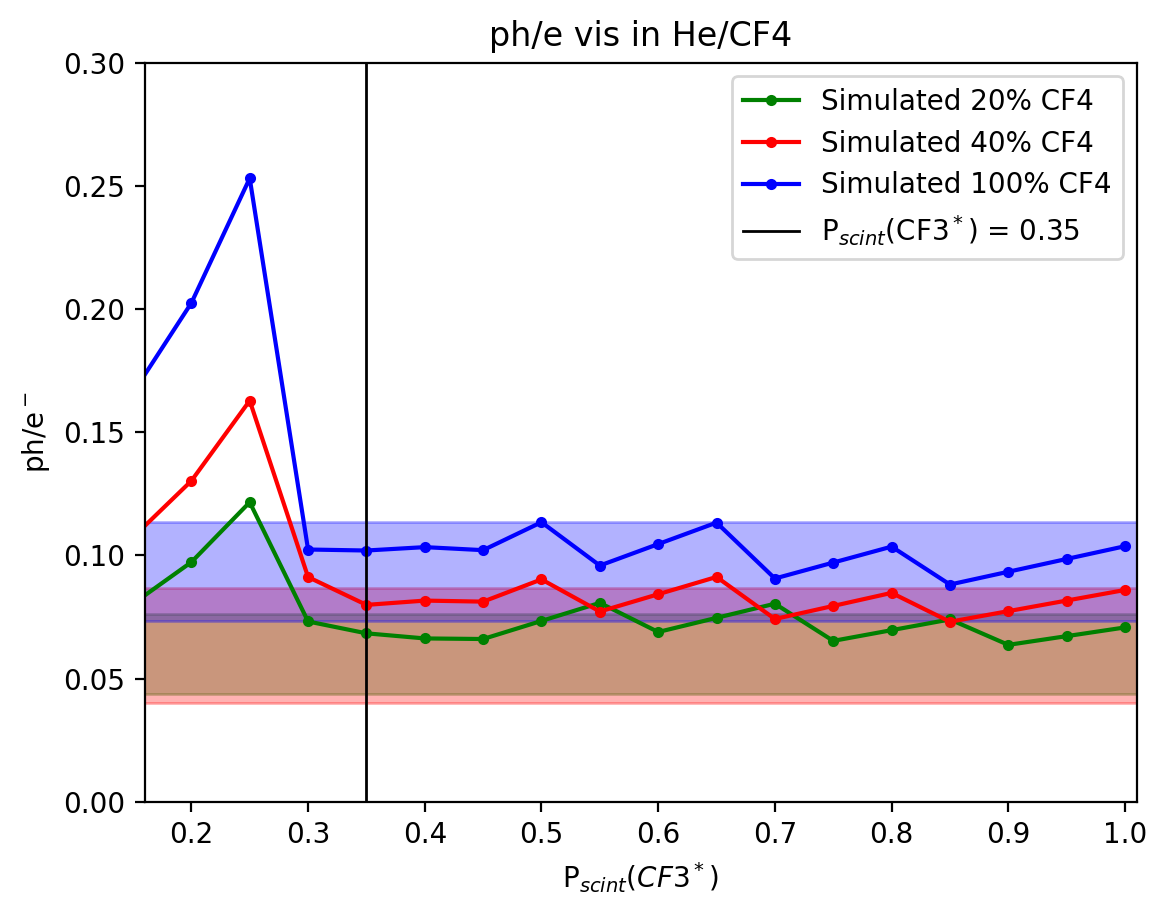

In [20]:
chi2s_list_he = []

fig_he, ax_he = plt.subplots( dpi = 200)
list_dic_Ps_to_states = [dic_Ps_to_states_he_20, dic_Ps_to_states_he_40, dic_Ps_to_states_100]
list_colors_he = ['g', 'r', 'b']
for dic_P, conc_b, ph_e_experimental, c, error in zip(list_dic_Ps_to_states, he_cf4_experimental_concs, he_cf4_experimental_phe_e_vis, list_colors_he, he_cf4_total_errors_vis):
    E_field = E_fields_he_cf4[conc_b]
    ph_e_vis_plot, ph_i_vis_plot, ph_e_uv_plot, ph_i_uv_plot = array_ph_e(0.1, 1.01, 0.05, E_field, dic_P, 1, 100-conc_b, conc_b, 'he', 0.05, 10000, **fit_parameters_wo_uncertainties)
    #ax_he.axhline(ph_e_experimental, label=f'Experimental {conc_b:d}% CF4', color=c)
    ax_he.fill_between(np.arange(0.1, 1.06, 0.05), ph_e_experimental - error, ph_e_experimental + error, color=c, alpha= 0.3)
    ax_he.plot(np.arange(0.1, 1.01, 0.05), ph_e_vis_plot, '.-', label=f'Simulated {conc_b:d}% CF4', color=c)
    #ax_he.plot(np.arange(0.1, 1.01, 0.05), ph_i_vis_plot, '^', label=f'Simulated {conc_b:d}% CF4', color=c)

    chi2_individual = np.array([(ph_e - ph_e_experimental) ** 2 / error ** 2  for ph_e in ph_e_vis_plot])
    # ax_chi2_he_vis.plot(np.arange(0.1, 1.01, 0.05), chi2_individual, '.', color=c, label=f'{conc_b}% CF4')
    # ax_chi2_he_vis.plot(np.arange(0.1, 1.01, 0.05), chi2_individual, '-', color=c)
    chi2s_list_he.append(chi2_individual)


ax_he.axvline(0.35, color='k', linewidth=1, label='P$_{scint}$(CF3$^*$) = 0.35')


ax_he.set_ylim(0, 0.3)
ax_he.set_xlim(0.16, 1.01)
ax_he.legend()
ax_he.set_xlabel('P$_{scint} (CF3^*)$')
ax_he.set_ylabel('ph/e$^-$')
ax_he.set_title('ph/e vis in He/CF4')


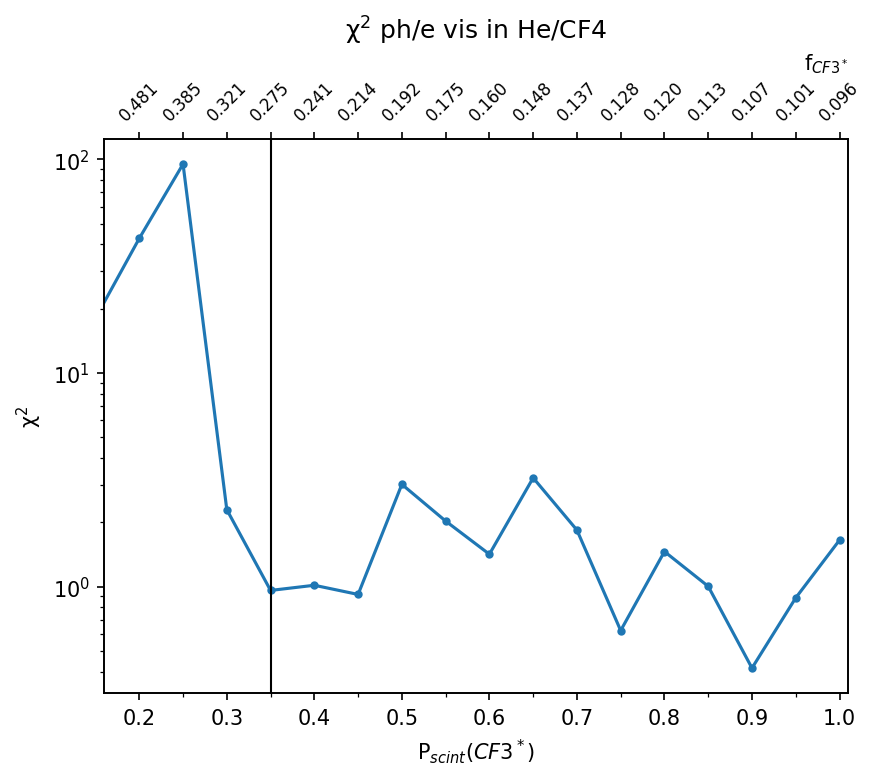

In [21]:
fig_chi2_he_vis, ax_chi2_he_vis = plt.subplots(dpi=150)


chi2 = sum(chi2s_list_he)
#ax_chi2_ar_vis.set_ylim(0, 10)
x_vals = np.arange(0.1, 1.01, 0.05)
ax_chi2_he_vis.plot(x_vals, chi2, '.-')


ax_chi2_he_vis.set_xlabel('P$_{scint} (CF3^*)$')
ax_chi2_he_vis.set_ylabel('\u03C7$^2$')
ax_chi2_he_vis.set_title('\u03C7$^2$ ph/e vis in He/CF4')
ax_chi2_he_vis.set_yscale('log')


levels_he_cf4 = pd.read_csv('./He_CF4_levels.csv')

mask_excited = levels_he_cf4['estado_excit'].notna()
data_excited = levels_he_cf4[mask_excited]

mask_direct = levels_he_cf4['f_osc'].notna()
data_direct = levels_he_cf4[mask_direct]


ax_labels_he = []

ax_labels_cf4 = []

for key, (idx_he, idx_cf4) in dic_Ps_to_states_100.items():

    ax_labels_he.append(data_excited.iloc[idx_ar]['estado_excit'])
    ax_labels_cf4.append(data_direct.iloc[idx_cf4]['energia_eV'])


# ax_labels_he_f = []
ax_labels_cf4_f = []
for P_CF3 in np.arange(0.1, 1.01, 0.05):
    # ax_labels_he_f.append(f"{0.2056 / P_CF3:.3f}")
    ax_labels_cf4_f.append(f"{0.09625 / P_CF3:.3f}")









ax_top_cf4 = ax_chi2_he_vis.twiny()

ax_top_cf4.set_xlim(ax_chi2_he_vis.get_xlim())


ax_top_cf4.set_xticks(x_vals)
ax_top_cf4.set_xticklabels(ax_labels_cf4_f, rotation=45, fontsize=8)

ax_top_cf4.set_xlabel("f$_{CF3^*}$", loc='right')
ax_top_cf4.set_xlim(0.16, 1.01)

ax_chi2_he_vis.set_xticks(np.arange(0.1, 1.01, 0.05), minor= True)
#ax_chi2_he_vis.grid(which='both', axis='x')



ax_chi2_he_vis.set_xlim(0.16, 1.01)
ax_chi2_he_vis.axvline(0.35, color='k', linewidth=1)


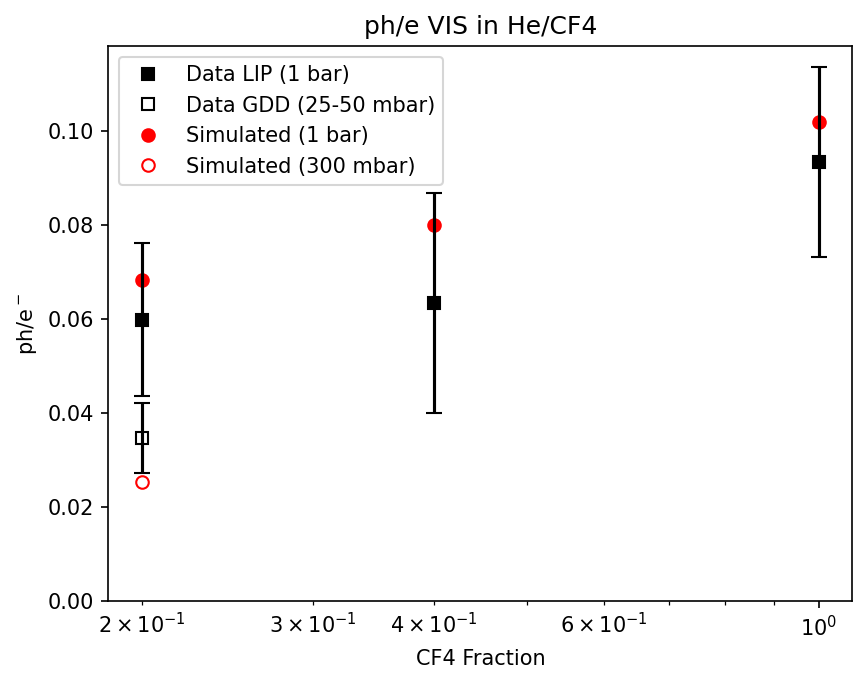

In [22]:
fig_he_vis, ax_he_vis = plt.subplots(dpi=150)

list_dic_Ps_to_states = [dic_Ps_to_states_he_20[0.35], dic_Ps_to_states_he_40[0.35], dic_Ps_to_states_100[0.35]]

for conc_b, c, ph_e_experimental, list_starting_states, error in zip(he_cf4_experimental_concs, list_colors_he, he_cf4_experimental_phe_e_vis, list_dic_Ps_to_states, he_cf4_total_errors_vis):

    n_start_transfer, n_start_dir = list_starting_states

    ph_e_vis, ph_e_uv, ph_i_vis, ph_i_uv, dic_values = ph_e(1, 'he', 100-conc_b, conc_b, E_fields_he_cf4[conc_b],
                                                            0.05, 10000, n_start_he=n_start_transfer, n_start_cf4=n_start_dir, **fit_parameters_wo_uncertainties)
    
    ax_he_vis.plot(conc_b / 100, ph_e_vis * 0.35, 'o', color='r', label=f'Sim VIS {conc_b}% CF4')
    ax_he_vis.errorbar(conc_b / 100, ph_e_experimental, yerr=error, marker='s', color='k', label=f'Exp VIS {conc_b}% CF4', capsize=4)
    


n_start_transfer, n_start_dir = dic_Ps_to_states_he_20[0.35]
ph_e_vis, ph_e_uv, ph_i_vis, ph_i_uv, dic_values = ph_e(0.3, 'he', 80, 20, 12.1,
                            0.57, 10000, n_start_he=n_start_transfer, n_start_cf4=n_start_dir, **fit_parameters_wo_uncertainties)
ax_he_vis.plot(0.2, ph_e_vis * 0.35, 'ro', markerfacecolor='none', label='Sim VIS 20% CF4, 300 mbar')
ax_he_vis.errorbar(0.2, yields_hecf4_8020_300_mbar['vis'], color='k', marker='s', markerfacecolor='none', yerr=0.3705805807148911 * he_cf4_total_errors_vis[-1], label='Exp VIS 20% CF4, 300 mbar', capsize=4)


legend_elements = [


    Line2D([0], [0], marker='s', linestyle='None',
           color='k', markerfacecolor='k', label='Data LIP (1 bar)'),

    Line2D([0], [0], marker='s', linestyle='None',
           color='k', markerfacecolor='none', label='Data GDD (25-50 mbar)'),
           

    Line2D([0], [0], marker='o', linestyle='None',
            color='r', markerfacecolor='r', label='Simulated (1 bar)'),

    Line2D([0], [0], marker='o', linestyle='None',
           color='r', markerfacecolor='none', label='Simulated (300 mbar)')
]

ax_he_vis.legend(loc='lower right')
ax_he_vis.set_xlabel('CF4 Fraction')
ax_he_vis.set_ylabel('ph/e$^-$')
ax_he_vis.set_title('ph/e VIS in He/CF4')
#ax_he_vis.set_xlim(0, 105)
ax_he_vis.set_ylim(0)
ax_he_vis.set_xscale('log')

ax_he_vis.legend(handles=legend_elements)

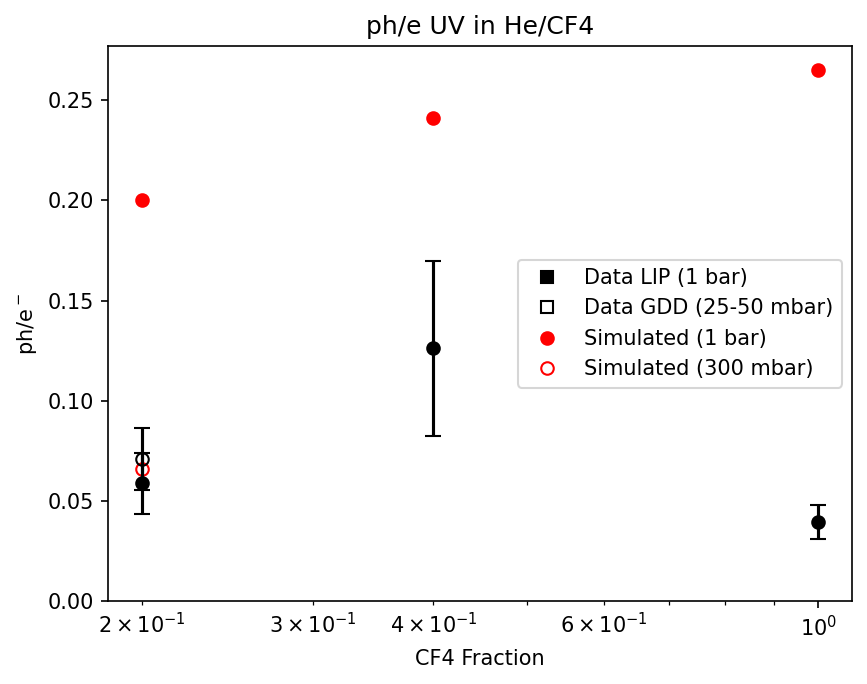

In [23]:
fig_he_uv, ax_he_uv = plt.subplots(dpi=150)
for conc_b, c, ph_e_experimental, error in zip(he_cf4_experimental_concs, list_colors_uv, he_cf4_experimental_phe_e_uv, he_cf4_total_errors_uv):
    ph_e_vis, ph_e_uv, ph_i_vis, ph_i_uv, dic_values = ph_e(1, 'he', 100-conc_b, conc_b, E_fields_he_cf4[conc_b],
                                                            0.05, 10000, **fit_parameters_wo_uncertainties)
    
    ax_he_uv.plot(conc_b / 100, ph_e_uv, 'o', color='r', label=f'Simulated UV {conc_b}% CF4')
    ax_he_uv.errorbar(conc_b / 100, ph_e_experimental, marker='o', color='k', yerr=error, label=f'Experimental UV {conc_b}% CF4', capsize=4)


n_start_transfer, n_start_dir = dic_Ps_to_states_he_20[0.35]
ph_e_vis, ph_e_uv, ph_i_vis, ph_i_uv, dic_values = ph_e(0.3, 'he', 80, 20, 12.1,
                            0.57, 10000, n_start_he=n_start_transfer, n_start_cf4=n_start_dir, **fit_parameters_wo_uncertainties)
ax_he_uv.plot(0.2, ph_e_uv, 'ro', markerfacecolor='none', label='Sim UV 20% CF4, 300 mbar')
ax_he_uv.errorbar(0.2, yields_hecf4_8020_300_mbar['uv'], marker='o', markerfacecolor='none', color='k', yerr= 1.8001303441629986 * he_cf4_total_errors_uv[-1], label='Exp UV 20% CF4, 300 mbar',capsize=4)


ax_he_uv.legend()
ax_he_uv.set_xlabel('CF4 Fraction')
ax_he_uv.set_ylabel('ph/e$^-$')
ax_he_uv.set_title('ph/e UV in He/CF4')
#ax_he_uv.set_xlim(0, 105)
ax_he_uv.set_ylim(0)
#ax_he_uv.set_xlim(0)
ax_he_uv.set_xscale('log')

ax_he_uv.legend(handles=legend_elements)

Text(0.5, 1.0, 'ph/e for differents fields in vs P$_{scint}$ for 5% CF4')

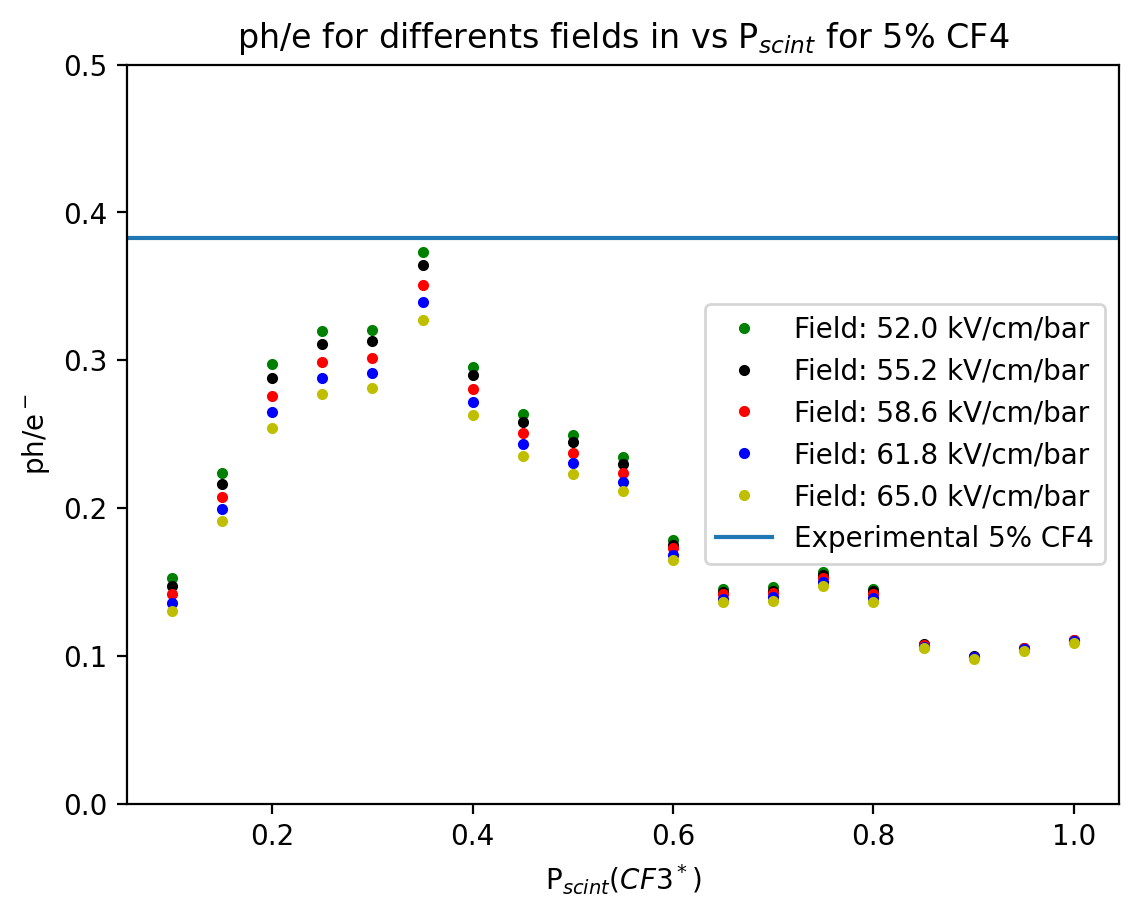

In [24]:
figure_cf4_5_vs_field, ax_5_field = plt.subplots(dpi=200)

list_fields_5 = [52, 55.2, 58.6, 61.8, 65]
list_colors_5 = list_colors + ['y']

for E_field, c in zip(list_fields_5, list_colors_5):
    ph_e_vis_plot_5_vs_fields, ph_i_vis_plot_5_vs_fields, ph_e_uv_plot_5_vs_fields, ph_i_uv_plot_5_vs_fields = array_ph_e(0.1, 1.01, 0.05, E_field, dic_Ps_to_states_5,
                                        1, 95, 5, 'ar', 0.05, 10000, **fit_parameters_wo_uncertainties)
    ax_5_field.plot(np.arange(0.1, 1.01, 0.05), ph_e_vis_plot_5_vs_fields, '.', label=f'Field: {E_field:.1f} kV/cm/bar', color=c)

ax_5_field.axhline(ar_cf4_experimental_phe_e_vis[0], label='Experimental 5% CF4')
ax_5_field.set_ylim(0, 0.5)
ax_5_field.legend()
ax_5_field.set_xlabel('P$_{scint} (CF3^*)$')
ax_5_field.set_ylabel('ph/e$^-$')
ax_5_field.set_title('ph/e for differents fields in vs P$_{scint}$ for 5% CF4')

Text(0.5, 1.0, 'ph/e for differents fields in vs P$_{scint}$ for 100% CF4')

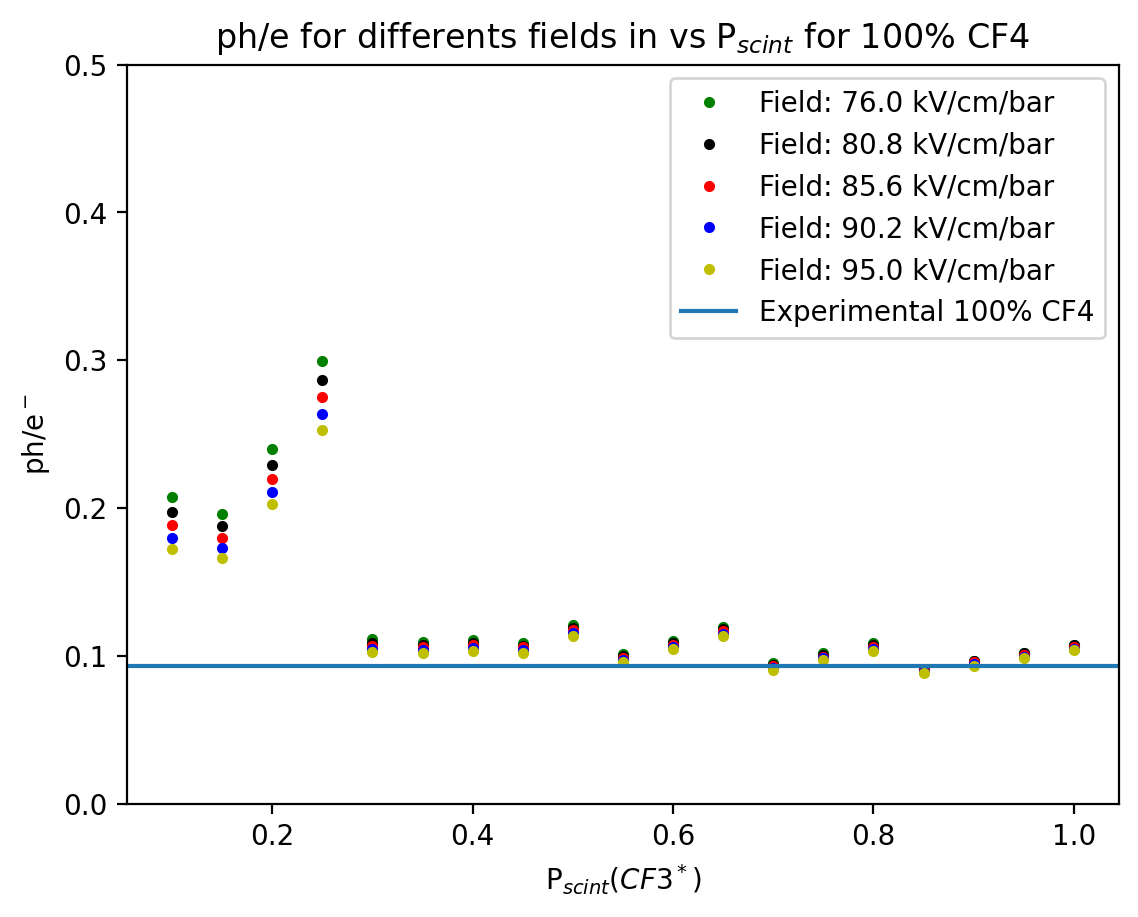

In [25]:
figure_cf4_100_vs_field, ax_100_field = plt.subplots(dpi=200)

list_fields_100 = [76, 80.8, 85.6, 90.2, 95]

for E_field, c in zip(list_fields_100, list_colors_5):
    ph_e_vis_plot_100_vs_fields, ph_i_vis_plot_100_vs_fields, ph_e_uv_plot_100_vs_fields, ph_i_uv_plot_100_vs_fields = array_ph_e(0.1, 1.01, 0.05, E_field, dic_Ps_to_states_100,
                                        1, 0, 100, 'ar', 0.05, 10000, **fit_parameters_wo_uncertainties)
    ax_100_field.plot(np.arange(0.1, 1.01, 0.05), ph_e_vis_plot_100_vs_fields, '.', label=f'Field: {E_field:.1f} kV/cm/bar', color=c)

ax_100_field.axhline(ar_cf4_experimental_phe_e_vis[-1], label='Experimental 100% CF4')
ax_100_field.set_ylim(0, 0.5)
ax_100_field.legend()
ax_100_field.set_xlabel('P$_{scint} (CF3^*)$')
ax_100_field.set_ylabel('ph/e$^-$')
ax_100_field.set_title('ph/e for differents fields in vs P$_{scint}$ for 100% CF4')